In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import operator

In [90]:
def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

In [91]:
def plot_two_histograms_with_stats(
    df1,
    df2,
    metric,
    bins='auto',
    density=False,
    x_range=None,
    title1='Seasonal',
    title2='Local'
):
    """
    Plot two histograms in one figure and display a combined stats box.
    Remaining params are shared.
    """
    
    if metric not in df1.columns or metric not in df2.columns:
        print("Incorrect metric name.")
        
    values1 = df1[metric]
    values2 = df2[metric]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    fig.suptitle(metric, fontsize=14)

    # Combined range
    min_val = min(np.min(values1), np.min(values2))
    max_val = max(np.max(values1), np.max(values2))

    if x_range is None:
        x_range = (min_val, max_val)

    def _add_hist_with_stats(ax, values, title):
        # Histogram
        ax.hist(values, bins=bins, density=density,
                range=x_range, color='skyblue', edgecolor='black')
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

        # Stats
        min_v = np.min(values)
        max_v = np.max(values)
        median_v = np.median(values.dropna())
        mean_v = np.mean(values)
        std_v = np.std(values)

        stats_lines = [
            f"Min: {min_v:.2f}",
            f"Max: {max_v:.2f}",
            f"Median: {median_v:.2f}",
            f"Mean: {mean_v:.2f}",
            f"Std: {std_v:.2f}",
        ]
        stats_text = "\n".join(stats_lines)

        font_size = max(8, min(10, 10 - len(stats_lines) // 2))

        ax.text(
            0.02, 0.98, stats_text,
            transform=ax.transAxes,
            va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=font_size,
        )

    _add_hist_with_stats(ax1, values1, title1)
    _add_hist_with_stats(ax2, values2, title2)

    plt.tight_layout()
    plt.show()


In [92]:
summary_df_seasonal = pd.read_csv('./results_seasonal_uc_1000_seed_42_daily_clipped.csv')

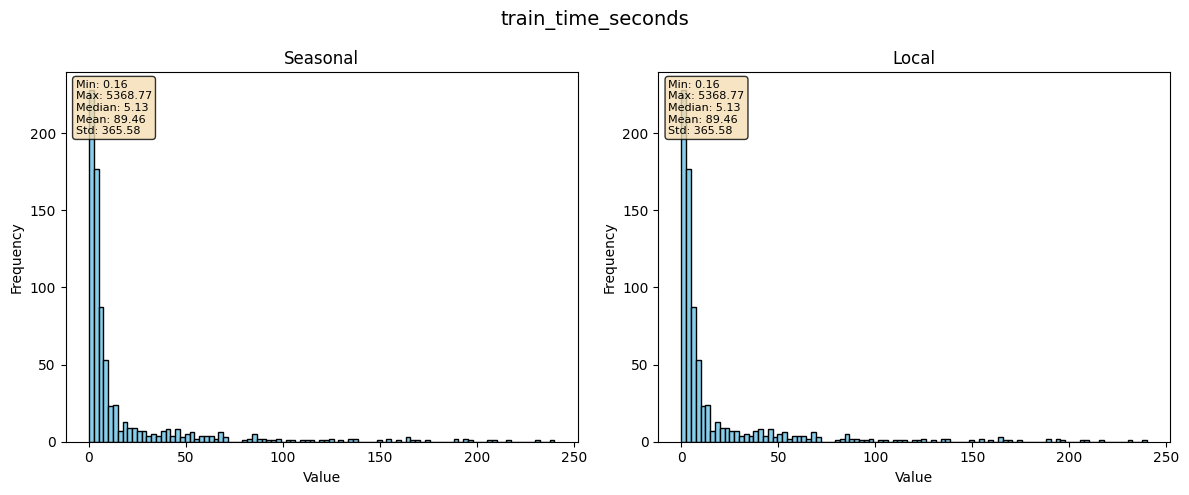

In [93]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_seasonal, 'train_time_seconds', x_range=(0,4*60))

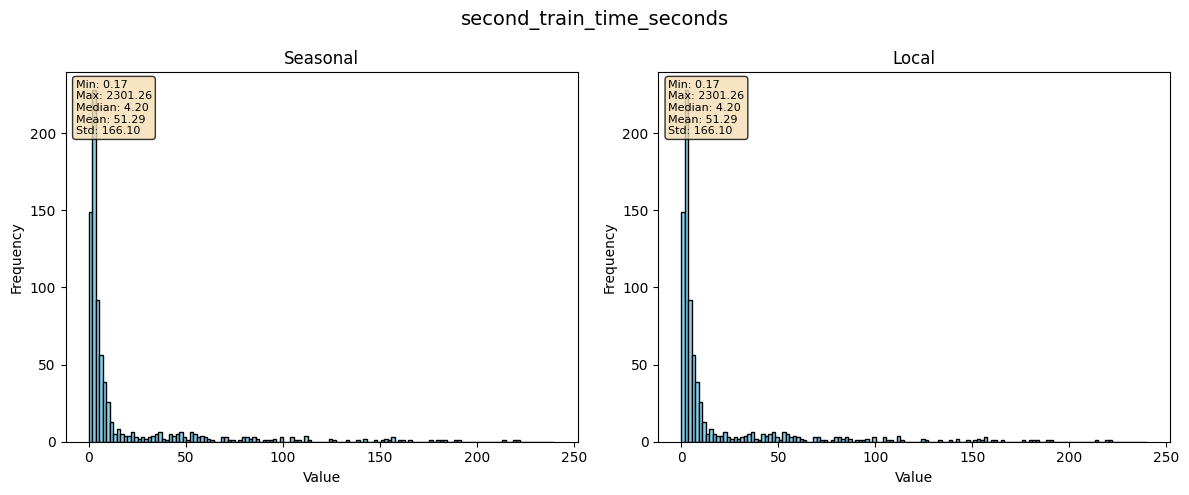

In [94]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_seasonal, 'second_train_time_seconds', x_range=(0,4*60))

In [95]:
df_candidates = get_candidates(summary_df_seasonal,
                       params=[
        #{"name": "converged_train", "value": False, "comparator": "=="},
        #{"name": "converged_second", "value": True, "comparator": "=="},
        #{"name": "status", "value": "success", "comparator": "=="},
        {"name": "train_time_seconds", "value": 5*60, "comparator": "<"},
        {"name": "second_train_time_seconds", "value": 5*60, "comparator": ">"},
        #{"name": "periodicity_seconds_train", "value": 1700, "comparator": "<="},
    ],)
display(df_candidates.head(5))
print(len(df_candidates))
display(df_candidates[['train_time_seconds', 'second_train_time_seconds']])

,filename,filepath,status,error,train_samples,second_train_samples,predict_samples,train_samples_filled,second_train_samples_filled,predict_samples_filled,...,metric_max_residual_nz,metric_min_residual_nz,metric_p75_ae_nz,metric_p90_ae_nz,metric_normalized_rmse_nz,metric_median_ape_nz,metric_prediction_bias_nz,metric_mpe_nz,metric_direction_accuracy_nz,anomalies_detected
103,80554,../data_w_diff_001\80554.csv,success,NaN,654.0,636.0,604.0,743.0,719.0,740.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
105,61494,../data_w_diff_001\61494.csv,success,NaN,2172.0,2222.0,2142.0,2231.0,2231.0,2159.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
160,145687,../data_w_diff_001\145687.csv,success,NaN,2826.0,2767.0,2737.0,2975.0,2975.0,2879.0,...,0.053837,0.000010,0.011011,0.020317,1.356761,0.851256,-0.008162,0.540457,0.508671,9.0
205,143722,../data_w_diff_001\143722.csv,success,NaN,663.0,635.0,607.0,743.0,742.0,719.0,...,0.218276,0.000188,0.035267,0.069938,1.078108,0.593216,-0.011247,-0.281876,0.602190,0.0
395,147352,../data_w_diff_001\147352.csv,success,NaN,733.0,731.0,709.0,744.0,742.0,719.0,...,0.790585,0.000197,0.122234,0.200975,0.602923,0.304281,-0.004772,-0.279188,0.657270,2.0


13


,train_time_seconds,second_train_time_seconds
103,105.814551,434.584565
105,63.470582,1225.216370
160,111.779701,326.098210
205,133.774318,483.188161
395,247.691297,314.900241
500,193.078530,528.396598
539,61.809717,446.343500
621,8.037535,580.140537
652,197.585971,773.153454
772,209.035706,342.667241


In [96]:
def plot_df_scatter(x_vals, y_vals, x_label, y_label, x_lim = None, y_lim = None):
    """
    Simple scatter: x = one df column, y = another df column.
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(x_vals, y_vals, color='steelblue', alpha=0.7, edgecolors='black')  # points in the middle[web:44][web:53]
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f'{x_label} vs {y_label}')
    plt.grid(True, linestyle=':', alpha=0.4)
    
    if x_lim is not None:
        plt.xlim(x_lim)  # expects (xmin, xmax)[web:62][web:68]
    if y_lim is not None:
        plt.ylim(y_lim)  # expects (ymin, ymax)[web:64][web:61]
    
    plt.tight_layout()
    plt.show()

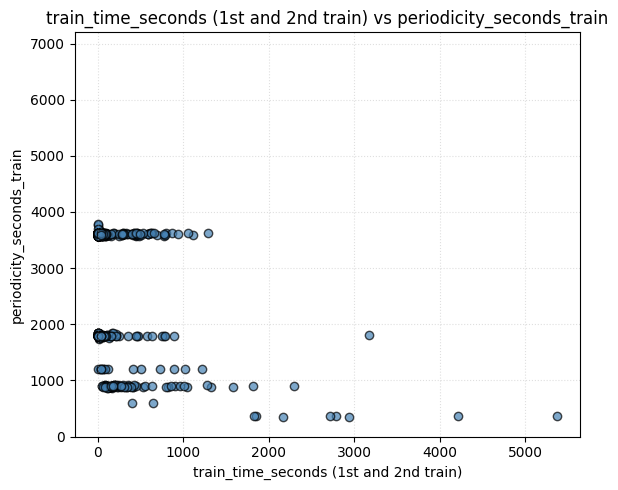

In [97]:
x_vals = pd.concat([summary_df_seasonal['train_time_seconds'], summary_df_seasonal['second_train_time_seconds']], axis=0, ignore_index=True)
y_vals = pd.concat([summary_df_seasonal['periodicity_seconds_train'], summary_df_seasonal['periodicity_seconds_second']], axis=0, ignore_index=True)

plot_df_scatter(x_vals, y_vals, 'train_time_seconds (1st and 2nd train)', 'periodicity_seconds_train', y_lim = (0, 120*60))

In [98]:

working_df_tmp1 = pd.DataFrame()
working_df_tmp1['number_of_gaps'] = summary_df_seasonal['train_samples_filled'] - summary_df_seasonal['train_samples']
working_df_tmp1['sgn_of_gaps'] = np.sign(working_df_tmp1['number_of_gaps'])
working_df_tmp1['percentage_of_gaps'] = np.abs(working_df_tmp1['number_of_gaps'] / summary_df_seasonal['train_samples_filled'])
working_df_tmp1['periodicity_seconds'] = summary_df_seasonal['periodicity_seconds_train']
working_df_tmp1['train_time_seconds'] = summary_df_seasonal['train_time_seconds']
working_df_tmp1['filename'] = summary_df_seasonal['filename']


working_df_tmp2 = pd.DataFrame()
working_df_tmp2['number_of_gaps'] = summary_df_seasonal['second_train_samples_filled'] - summary_df_seasonal['second_train_samples']
working_df_tmp2['sgn_of_gaps'] = np.sign(working_df_tmp2['number_of_gaps'])
working_df_tmp2['percentage_of_gaps'] = np.abs(working_df_tmp2['number_of_gaps'] / summary_df_seasonal['second_train_samples_filled'])
working_df_tmp2['periodicity_seconds'] = summary_df_seasonal['periodicity_seconds_second']
working_df_tmp2['train_time_seconds'] = summary_df_seasonal['second_train_time_seconds']
working_df_tmp2['filename'] = summary_df_seasonal['filename']

working_df = pd.concat([working_df_tmp1, working_df_tmp2], axis=0, ignore_index=True)
display(working_df)

,number_of_gaps,sgn_of_gaps,percentage_of_gaps,periodicity_seconds,train_time_seconds,filename
0,NaN,NaN,NaN,NaN,NaN,150147
1,NaN,NaN,NaN,NaN,NaN,83002
2,NaN,NaN,NaN,NaN,NaN,114101
3,-1.0,-1.0,0.033333,86388.0,1.175504,111693
4,31.0,1.0,0.041949,3619.0,2.423596,123020
...,...,...,...,...,...,...
1995,21.0,1.0,0.028226,3596.0,36.699328,121709
1996,79.0,1.0,0.053127,1800.0,43.060488,139086
1997,13.0,1.0,0.001758,350.0,NaN,126240
1998,807.0,1.0,0.373784,1200.0,899.462484,66514


In [99]:
too_long = get_candidates(working_df, [{"name": "train_time_seconds", "value": 170, "comparator": ">"}])
print(len(too_long))
display(too_long)

133


,number_of_gaps,sgn_of_gaps,percentage_of_gaps,periodicity_seconds,train_time_seconds,filename
46,188.0,1.0,0.063172,886.0,230.620774,144617
51,677.0,1.0,0.227640,913.0,188.906943,145679
66,209.0,1.0,0.070323,915.0,206.550715,148000
72,324.0,1.0,0.108908,910.0,241.791441,131721
91,2.0,1.0,0.000676,905.0,905.592475,110902
...,...,...,...,...,...,...
1928,10.0,1.0,0.013550,3619.0,453.661096,138403
1968,20.0,1.0,0.006725,902.0,176.020306,140689
1991,382.0,1.0,0.518318,3600.0,496.423334,110189
1992,11.0,1.0,0.016393,3600.0,281.660682,92992


In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
)


def fit_train_time_tree(summary_df_seasonal, feature_cols, threshold=120,
                        max_depth=None, train_split=True, random_state=42):

    # 1) Create binary target: 1 if train_time_seconds > threshold else 0
    df = summary_df_seasonal.copy()
    df["target_long_train"] = (df["train_time_seconds"] > threshold).astype(int)

    X = df[feature_cols]
    y = df["target_long_train"]

    # 2) Train/test split (optional)
    if train_split:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
    else:
        X_train, X_test, y_train, y_test = X, None, y, None

    # 3) Define and train the decision tree classifier
    clf = DecisionTreeClassifier(
        criterion="gini",
        max_depth=max_depth,
        random_state=random_state,
    )
    clf.fit(X_train, y_train)

    # Helper to print metrics for a split
    def print_metrics(split_name, y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", pos_label=1
        )
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        print(f"\n{split_name} metrics:")
        print(f"Accuracy:  {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall:    {rec:.3f}")
        print(f"F1:        {f1:.3f}")
        print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    # 4) Metrics on train
    y_pred_train = clf.predict(X_train)
    print_metrics("Train", y_train, y_pred_train)

    # 5) Metrics on test (if split)
    if train_split:
        y_pred_test = clf.predict(X_test)
        print_metrics("Test", y_test, y_pred_test)

    return clf, X_train, y_train, X_test, y_test


In [101]:
from sklearn.tree import plot_tree  # or: from sklearn import tree; tree.plot_tree

def plot_decision_tree(clf, feature_names, class_names=("short", "long"),
                       figsize=(16, 8), dpi=150):
    plt.figure(figsize=figsize, dpi=dpi)
    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=[str(c) for c in class_names],
        filled=True,
        rounded=True,
        impurity=True,      # show Gini
        proportion=False,   # show sample counts, not proportions
    )
    plt.tight_layout()
    plt.show()


In [102]:
feature_cols=[
        #"number_of_gaps_train",
        "percentage_of_gaps",
        "sgn_of_gaps",
        "periodicity_seconds",
    ]

clf, X_train, y_train, X_test, y_test = fit_train_time_tree(working_df, 
    feature_cols=feature_cols,
    threshold=170,
    train_split=False)


Train metrics:
Accuracy:  0.986
Precision: 1.000
Recall:    0.789
F1:        0.882
TN: 1867, FP: 0, FN: 28, TP: 105


In [118]:
# Files that are actually long (y_test == 1) and predicted long (TP), etc.
y_pred_train = clf.predict(working_df[['percentage_of_gaps', 'sgn_of_gaps', 'periodicity_seconds']])

results_df = working_df.loc[X_train.index, ["filename", "train_time_seconds"]].copy()
results_df["y_true"] = y_train.values
results_df["y_pred"] = y_pred_train

# All files predicted as long
predicted_long = results_df[results_df["y_pred"] == 1]['filename']
print(predicted_long)
predicted_long_filenames = predicted_long.unique()
print(f'Number of unique ones: {len(predicted_long_filenames)}')

# True long files (ground truth)
true_long = results_df[results_df["y_true"] == 1]
print(len(true_long))

# False negatives (long but predicted short)
false_negatives = results_df[(results_df["y_true"] == 1) & (results_df["y_pred"] == 0)]
print(len(false_negatives))

46      144617
51      145679
66      148000
72      131721
91      110902
         ...  
1901    133605
1968    140689
1991    110189
1992     92992
1998     66514
Name: filename, Length: 105, dtype: int64
Number of unique ones: 76
133
28


In [119]:
print(f"The df had a lenght of {len(summary_df_seasonal)} and will be now long {len(summary_df_seasonal[~summary_df_seasonal['filename'].isin(predicted_long_filenames)])}")

The df had a lenght of 1000 and will be now long 924


In [ ]:
import pickle

with open("train_time_tree.pkl", "wb") as f:
    pickle.dump(clf, f)

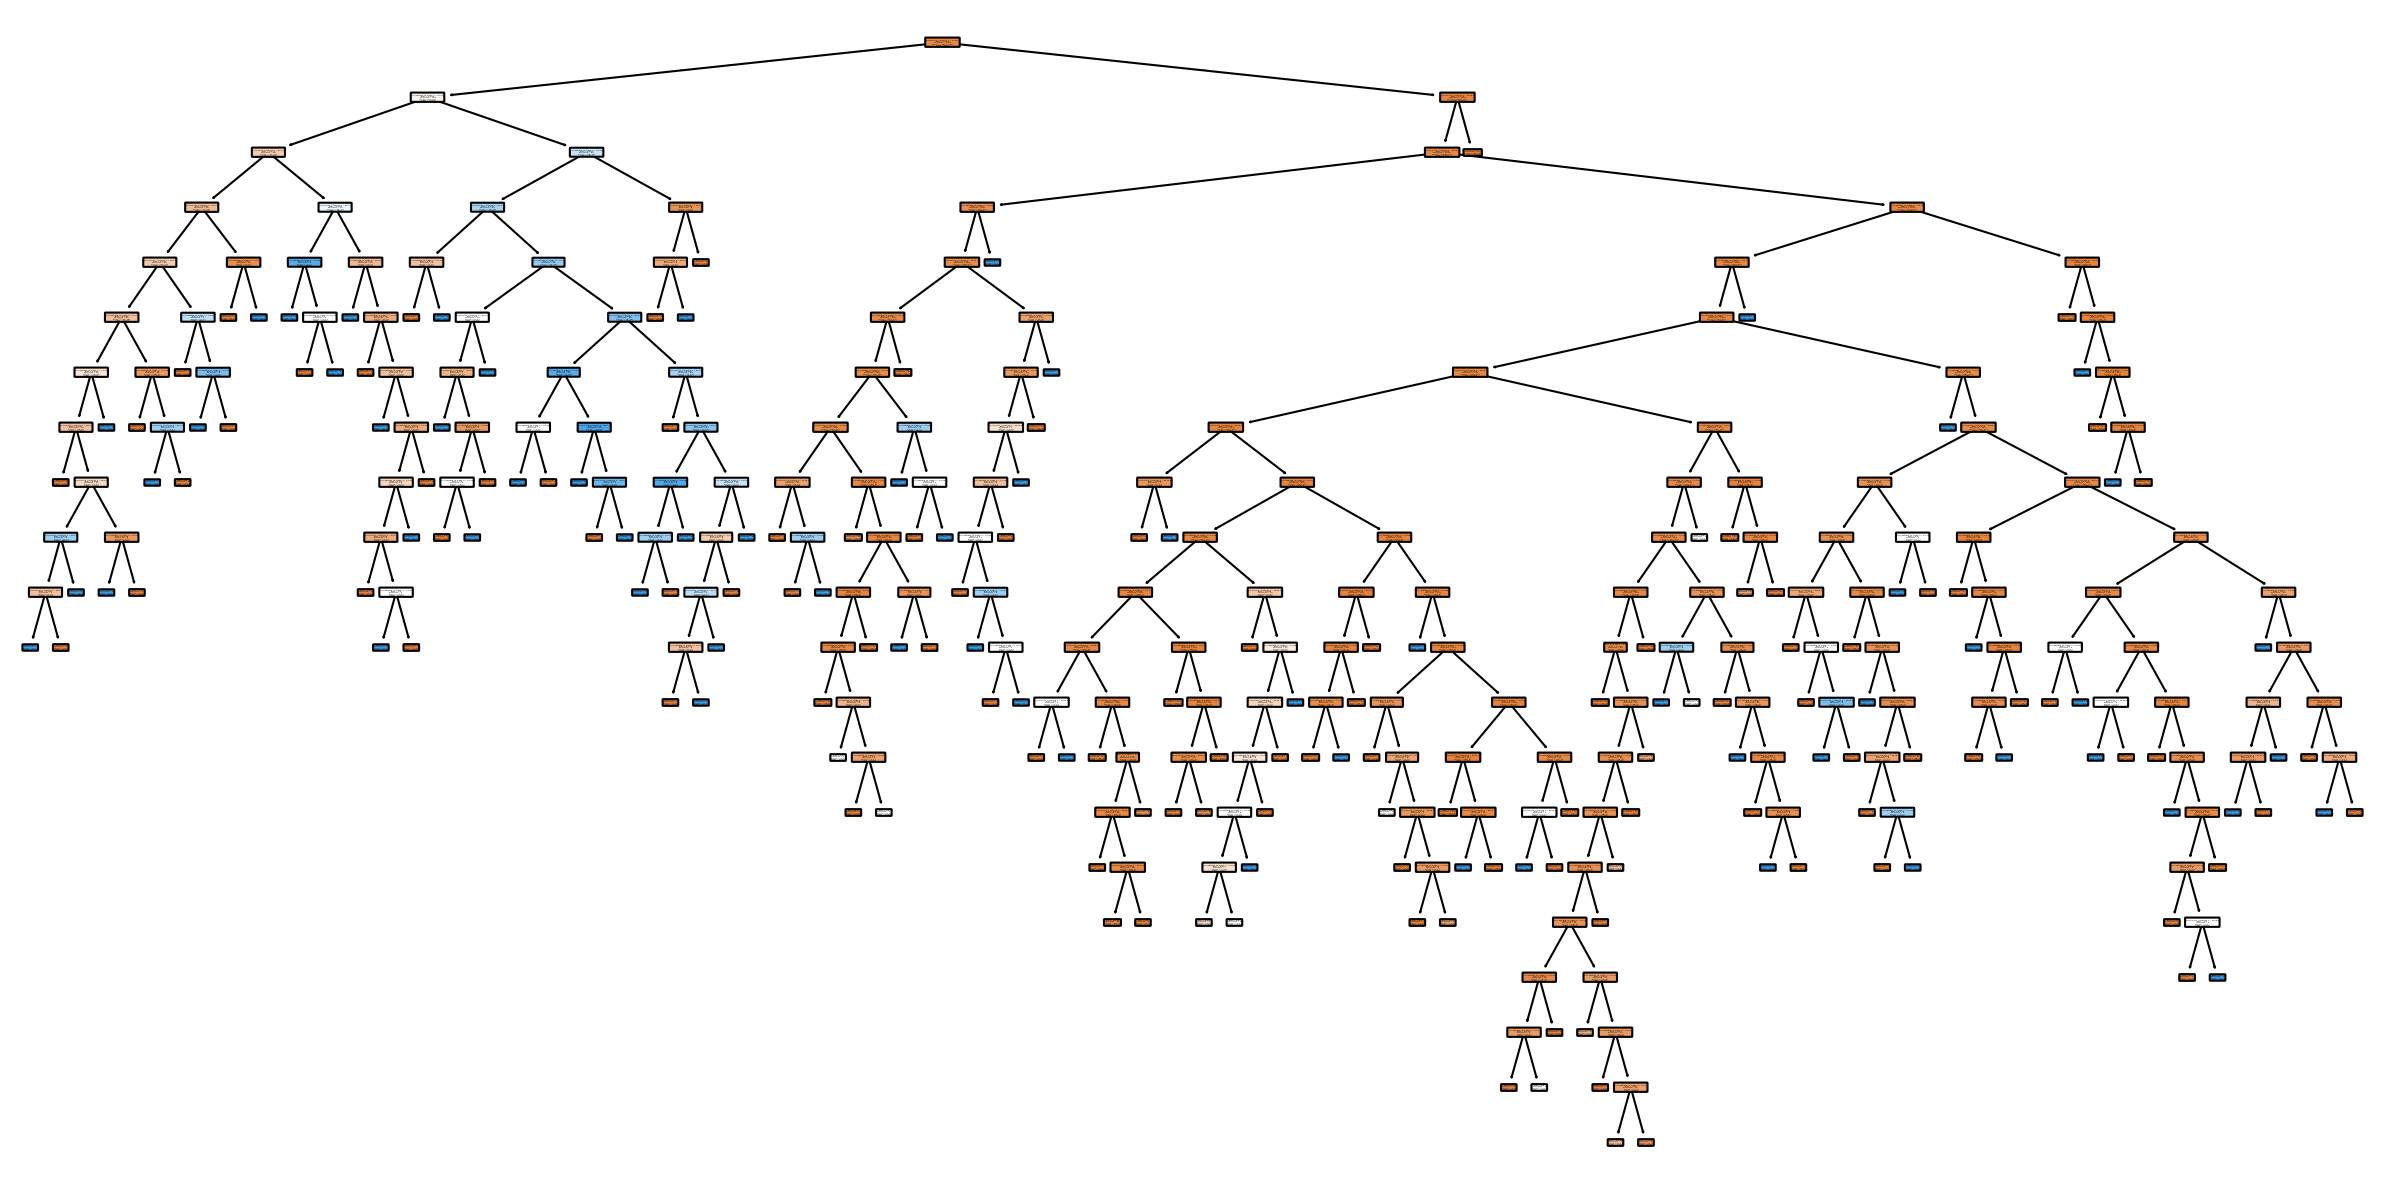

In [ ]:
plot_decision_tree(clf, feature_names=feature_cols,
                   class_names=("short", "long"))
